
# Telecom Churn Prediction

Este notebook apresenta o desenvolvimento do projeto Telecom Churn Prediction, voltado à análise de dados de clientes de telecomunicações e à previsão de cancelamento de serviços (Customer Churn).

O projeto contempla análise exploratória, preparação dos dados, treinamento, avaliação e comparação de modelos de classificação, utilizando Python e técnicas de Machine Learning.
  

### Verificação da conexão com Google Colab

Antes da configuração do ambiente, foi realizado um teste para verificar se o notebook estava executando no servidor remoto do Google Colab, e não no ambiente Python local.

A verificação identifica o executável Python, o sistema operacional e a presença de uma variável de ambiente característica do Google Colab.

In [9]:
import sys
import os

print("Python:", sys.executable)
print("Sistema:", os.name)
print("Ambiente Colab:", "COLAB_RELEASE_TAG" in os.environ)

Python: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\.venv\Scripts\python.exe
Sistema: nt
Ambiente Colab: False


### Identificação e configuração do ambiente Python

Esta etapa identifica as características do ambiente de execução, incluindo a versão do Python, o sistema operacional e o diretório de trabalho.

Essas informações auxiliam na reprodutibilidade dos experimentos e na identificação de diferenças entre a execução local e o ambiente remoto do Google Colab.

A definição dos caminhos do projeto será realizada separadamente, considerando que os arquivos locais do VS Code não estão automaticamente disponíveis no servidor remoto.

In [10]:
# Identificação do ambiente de execução

import sys
import platform
from pathlib import Path

# Informações do ambiente
VERSAO_PYTHON = platform.python_version()
SISTEMA_OPERACIONAL = platform.system()
EXECUTAVEL_PYTHON = sys.executable
DIRETORIO_ATUAL = Path.cwd()

# Exibição das informações
print(f"Versão do Python: {VERSAO_PYTHON}")
print(f"Sistema operacional: {SISTEMA_OPERACIONAL}")
print(f"Executável Python: {EXECUTAVEL_PYTHON}")
print(f"Diretório de trabalho: {DIRETORIO_ATUAL}")

Versão do Python: 3.11.5
Sistema operacional: Windows
Executável Python: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\.venv\Scripts\python.exe
Diretório de trabalho: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\notebooks


In [11]:
# ============================================================
# CONFIGURAÇÃO DOS CAMINHOS E IMPORTAÇÃO DOS MÓDULOS DO PROJETO
# ============================================================

from pathlib import Path
import sys

# Localiza a raiz do projeto
RAIZ_PROJETO = Path.cwd().resolve()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

# Adiciona a raiz ao caminho de importação
if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

print(f"Raiz do projeto: {RAIZ_PROJETO}")

Raiz do projeto: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction


## Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para a análise exploratória de dados (EDA).

- **Pandas:** manipulação, inspeção e análise de dados tabulares.
- **NumPy:** operações numéricas e estatísticas.
- **Matplotlib:** criação e personalização de gráficos.
- **Seaborn:** visualizações estatísticas, distribuições e correlações.


In [34]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos internos do projeto
from src.data.dataset import carregar_dataset
from src.preprocessing.duplicates import remover_duplicatas
from src.preprocessing.imputation import criar_imputador, COLUNAS_IMPUTACAO
from src.features.engineering import criar_gasto_medio_mensal
from src.splitting.split import dividir_dados
from src.splitting.balancing import balancear_treinamento

# Atualização automática dos módulos durante o desenvolvimento
%load_ext autoreload
%autoreload 2

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Verificação das versões
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

print("\nBibliotecas importadas com sucesso!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pandas: 3.0.6
NumPy: 2.4.6
Matplotlib: 3.11.2
Seaborn: 0.13.2

Bibliotecas importadas com sucesso!


## Fase 1 — Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados (EDA) tem como objetivo compreender a estrutura, a distribuição e as características do conjunto de dados antes da construção dos modelos preditivos.

Nesta etapa, serão realizadas:

1. Inspeção das dimensões e dos tipos de dados.
2. Análise estatística descritiva das variáveis.
3. Verificação de valores ausentes e registros duplicados.
4. Visualização da distribuição das variáveis preditoras.
5. Análise da proporção das classes da variável-alvo (Churn).
6. Investigação das correlações entre variáveis numéricas utilizando o coeficiente de Pearson.
7. Interpretação dos resultados e identificação de possíveis necessidades de pré-processamento.

Os resultados obtidos orientarão as decisões técnicas das próximas etapas do pipeline de Machine Learning.

In [13]:
from pathlib import Path

print("Pasta atual:", Path.cwd())
print("Pasta src disponível:", Path("src").exists())

Pasta atual: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\notebooks
Pasta src disponível: False


### 1.1 — Carregamento do Dataset

Nesta etapa, será carregado o arquivo `dataset_telecom.csv`, utilizando a função `carregar_dataset()` definida no módulo `src/data/dataset.py`.

Em seguida, serão verificadas as dimensões e as primeiras observações do conjunto de dados.

In [14]:
# ============================================================
# 1.1 — CARREGAMENTO DO DATASET
# ============================================================

CAMINHO_DATASET = RAIZ_PROJETO / "data" / "raw" / "dataset_telecom.csv"

df = carregar_dataset(CAMINHO_DATASET)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

display(df.head())

Linhas: 7068
Colunas: 21


,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,meses_contrato,servico_telefone,linhas_multiplas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,valor_total,cancelou
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#### Observações

O dataset foi carregado com sucesso, apresentando **7.068 registros e 21 variáveis**.

A visualização inicial das cinco primeiras observações permite conhecer a organização dos dados e confirmar o carregamento das informações.

### 1.2 — Estrutura e Tipos de Dados

Nesta etapa, será examinada a estrutura do dataset, identificando os nomes das variáveis, seus tipos de dados e a quantidade de valores não nulos.

Essa análise permitirá reconhecer variáveis numéricas e categóricas, além de identificar possíveis problemas que deverão ser considerados nas próximas etapas.

In [15]:
# ============================================================
# 1.2 — ESTRUTURA E TIPOS DE DADOS
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7068 entries, 0 to 7067
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7068 non-null   str    
 1   genero                7068 non-null   str    
 2   idoso                 7068 non-null   int64  
 3   tem_parceiro          7068 non-null   str    
 4   tem_dependentes       7068 non-null   str    
 5   meses_contrato        6784 non-null   float64
 6   servico_telefone      7068 non-null   str    
 7   linhas_multiplas      7068 non-null   str    
 8   servico_internet      7068 non-null   str    
 9   seguranca_online      7068 non-null   str    
 10  backup_online         7068 non-null   str    
 11  protecao_dispositivo  7068 non-null   str    
 12  suporte_tecnico       7068 non-null   str    
 13  streaming_tv          7068 non-null   str    
 14  streaming_filmes      7068 non-null   str    
 15  tipo_contrato         7068 non-n

#### Observações

O dataset apresenta **16 variáveis do tipo `str`, 3 do tipo `float64` e 2 do tipo `int64`**, reunindo informações cadastrais, contratuais e financeiras.

Foram identificados valores ausentes em três variáveis:

- `meses_contrato`: 284 registros (4,02%);
- `valor_mensal`: 354 registros (5,01%);
- `valor_total`: 11 registros (0,16%).

A variável-alvo `cancelou` não apresenta valores ausentes. As variáveis `idoso` e `cancelou`, embora armazenadas como inteiros, deverão ser consideradas conforme sua natureza categórica.

Os valores ausentes serão investigados na etapa de qualidade dos dados, antes de qualquer decisão de tratamento.

### 1.3 — Análise Estatística Descritiva

Nesta etapa, serão analisadas as principais estatísticas descritivas das variáveis numéricas do dataset, utilizando o método `describe()` da biblioteca Pandas.

Serão observados:

- **Count:** quantidade de valores não nulos.
- **Mean:** média aritmética.
- **Std:** desvio-padrão, que indica a dispersão dos valores.
- **Min e Max:** valores mínimo e máximo.
- **25%, 50% e 75%:** quartis da distribuição, sendo 50% a mediana.

Essa análise permitirá compreender a distribuição das variáveis, identificar possíveis valores extremos e reconhecer características relevantes para a futura construção do modelo preditivo.

In [16]:
# ============================================================
# 1.3 — ANÁLISE ESTATÍSTICA DESCRITIVA
# ============================================================

# Estatísticas descritivas das variáveis numéricas
estatisticas_numericas = df.describe()

# Exibição dos resultados com duas casas decimais
display(estatisticas_numericas.round(2))

,idoso,meses_contrato,valor_mensal,valor_total,cancelou
count,7068.00,6784.00,6714.00,7057.00,7068.00
mean,0.16,32.36,65.87,2283.28,0.26
std,0.37,24.56,40.99,2265.86,0.44
min,0.00,0.00,18.25,18.80,0.00
25%,0.00,9.00,35.65,401.95,0.00
50%,0.00,29.00,70.35,1398.60,0.00
75%,0.00,55.00,89.95,3791.60,1.00
max,1.00,72.00,921.40,8684.80,1.00


#### Observações

A análise descritiva revelou um possível valor atípico em `valor_mensal`, cujo máximo (921,40) está consideravelmente acima do terceiro quartil (89,95).

Também foram observados indícios de desbalanceamento na variável-alvo `cancelou`, com média de aproximadamente 0,265, considerando a codificação binária (0 e 1).

Esses aspectos serão investigados nas próximas etapas da análise exploratória.

### 1.4 — Distribuição do Tempo de Contrato

Nesta etapa, será analisada a distribuição da variável `meses_contrato`, que representa o tempo de relacionamento dos clientes com a empresa.

Será utilizado um histograma para identificar a concentração dos registros, a dispersão dos valores e possíveis padrões de permanência.

A visualização permitirá investigar características relevantes para a futura previsão de cancelamento (*churn*).

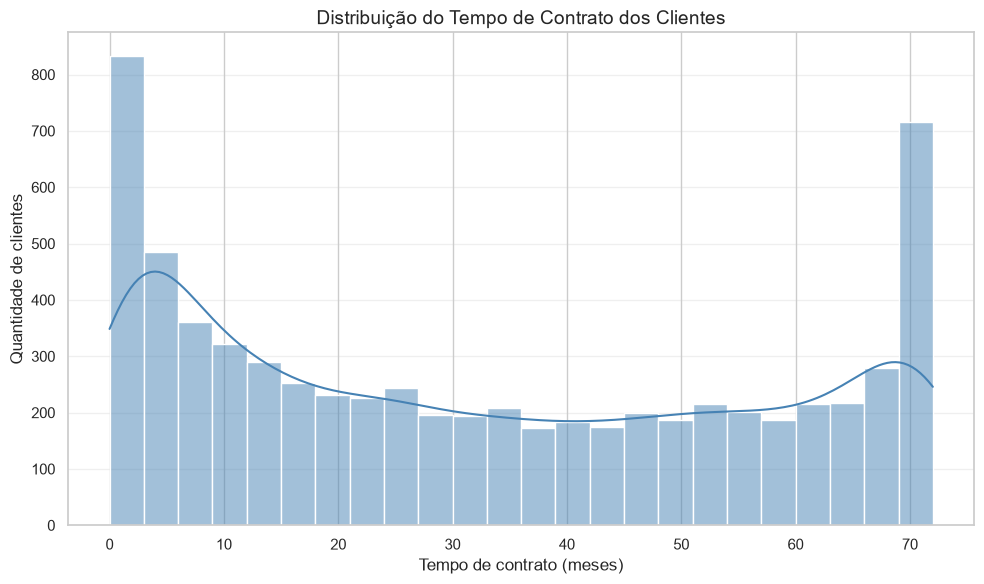

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\01_distribuicao_tempo_contrato.png


In [18]:
# ============================================================
# 1.4 — DISTRIBUIÇÃO DO TEMPO DE CONTRATO
# ============================================================

# Diretório de saída dos gráficos
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

# Construção do histograma
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="meses_contrato",
    bins=24,
    kde=True,
    color="steelblue",
    ax=ax
)

# Configuração da visualização
ax.set_title("Distribuição do Tempo de Contrato dos Clientes", fontsize=14)
ax.set_xlabel("Tempo de contrato (meses)")
ax.set_ylabel("Quantidade de clientes")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Salvamento automático do gráfico
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "01_distribuicao_tempo_contrato.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

# Exibição no notebook
plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A distribuição do tempo de contrato apresenta concentrações mais elevadas entre clientes com poucos meses de relacionamento e aqueles próximos de 72 meses.

Esse comportamento sugere a presença de dois perfis distintos: clientes recentes e clientes com longo histórico de permanência.

A variável `meses_contrato` poderá ser relevante para a previsão de churn. Entretanto, será necessário comparar sua distribuição entre clientes que cancelaram e aqueles que permaneceram para verificar essa relação.

### 1.5 — Distribuição da Variável-Alvo (Churn)

Nesta etapa, será analisada a distribuição da variável-alvo `cancelou`, utilizando um gráfico de barras para comparar a quantidade de clientes que permaneceram e daqueles que cancelaram o serviço.

Também serão calculadas as frequências absolutas e relativas de cada classe, permitindo avaliar o possível desbalanceamento dos dados e suas implicações para o treinamento do modelo.

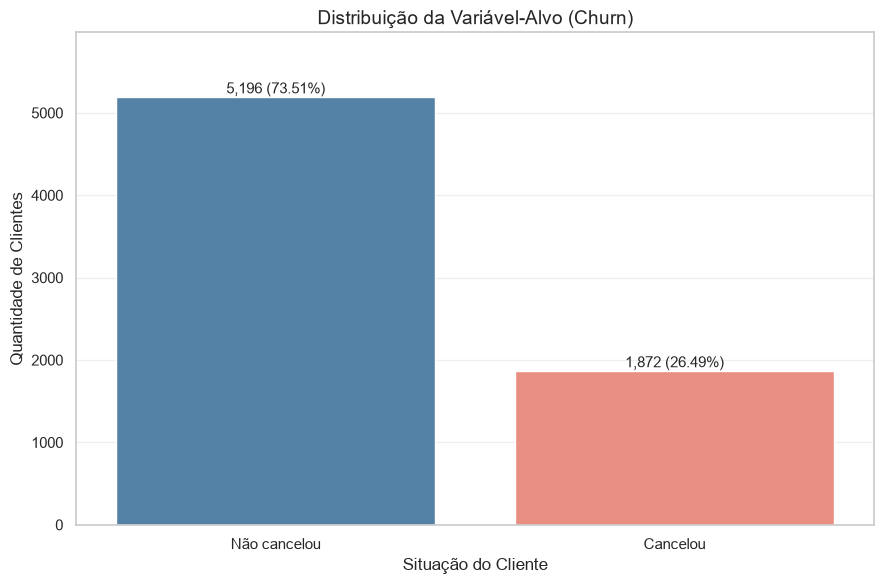

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\02_distribuicao_churn.png


In [19]:
# ============================================================
# 1.5 — DISTRIBUIÇÃO DA VARIÁVEL-ALVO (CHURN)
# ============================================================

# Frequências absolutas e percentuais
contagem_churn = df["cancelou"].value_counts().sort_index()
percentual_churn = df["cancelou"].value_counts(normalize=True).sort_index() * 100

# Construção do gráfico
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    x=["Não cancelou", "Cancelou"],
    y=contagem_churn.values,
    hue=["Não cancelou", "Cancelou"],
    palette=["steelblue", "salmon"],
    legend=False,
    ax=ax
)

# Exibição das quantidades e percentuais
for i, (quantidade, percentual) in enumerate(
    zip(contagem_churn.values, percentual_churn.values)
):
    ax.text(
        i,
        quantidade + 40,
        f"{quantidade:,} ({percentual:.2f}%)",
        ha="center",
        fontsize=11
    )

# Configuração da visualização
ax.set_title("Distribuição da Variável-Alvo (Churn)", fontsize=14)
ax.set_xlabel("Situação do Cliente")
ax.set_ylabel("Quantidade de Clientes")
ax.set_ylim(0, contagem_churn.max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Salvamento automático
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "02_distribuicao_churn.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A variável-alvo `cancelou` apresenta uma distribuição desbalanceada, com **73,51% dos clientes permanecendo ativos** e **26,49% registrando cancelamento**.

A classe majoritária possui aproximadamente 2,8 vezes mais registros que a classe minoritária.

Esse desbalanceamento deverá ser considerado na modelagem, especialmente na escolha das métricas de avaliação, como precisão, recall e F1-score, pois a acurácia isolada pode produzir uma avaliação inadequada do desempenho preditivo.

### 1.6 — Análise de Correlação de Pearson

Nesta etapa, será utilizada a correlação de Pearson para investigar a intensidade e a direção das relações lineares entre as variáveis numéricas do dataset.

Os coeficientes variam de -1 a +1, sendo valores próximos de zero indicativos de ausência de correlação linear relevante.

O mapa de calor permitirá identificar associações entre as variáveis e possíveis relações com a variável-alvo `cancelou`, contribuindo para a análise das características preditoras.

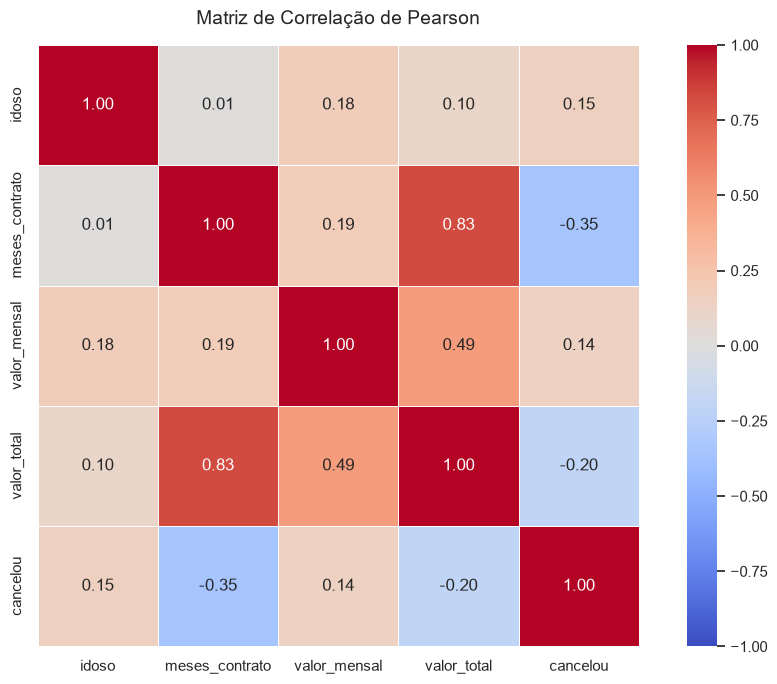

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\03_correlacao_pearson.png


In [20]:
# ============================================================
# 1.6 — ANÁLISE DE CORRELAÇÃO DE PEARSON
# ============================================================

# Seleção das variáveis numéricas
dados_numericos = df.select_dtypes(include="number")

# Cálculo da matriz de correlação
matriz_correlacao = dados_numericos.corr(method="pearson")

# Construção do mapa de calor
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title(
    "Matriz de Correlação de Pearson",
    fontsize=14,
    pad=15
)

plt.tight_layout()

# Salvamento automático
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "03_correlacao_pearson.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A matriz de correlação de Pearson revelou as seguintes relações:

- **`meses_contrato` × `cancelou` (-0,35):** correlação negativa moderada, indicando que clientes com maior tempo de contrato tendem a apresentar menor frequência de cancelamento.
- **`valor_total` × `cancelou` (-0,20):** correlação negativa fraca, sugerindo uma associação entre maior valor acumulado e menor ocorrência de churn.
- **`valor_mensal` × `cancelou` (0,14):** correlação positiva fraca, indicando uma possível associação entre mensalidades mais elevadas e cancelamento.
- **`idoso` × `cancelou` (0,15):** correlação positiva fraca, sugerindo maior ocorrência de cancelamento entre clientes classificados como idosos.
- **`meses_contrato` × `valor_total` (0,83):** correlação positiva forte, indicando elevada associação entre o tempo de contrato e o valor total acumulado.

A correlação entre `meses_contrato` e `valor_total` merece atenção durante a modelagem, especialmente em algoritmos sensíveis à multicolinearidade.

Os resultados indicam que o tempo de contrato pode ser uma variável preditora relevante para o churn. Entretanto, **correlação não implica causalidade**, e essas associações deverão ser avaliadas em conjunto com as demais variáveis do dataset.

### 1.7 — Conclusão da Análise Exploratória

A análise exploratória dos **7.068 registros e 21 variáveis** identificou padrões relevantes para a previsão de cancelamento de clientes (*churn*).

Observou-se um **desbalanceamento da variável-alvo**, com 26,49% de cancelamentos, além de uma associação negativa entre o tempo de contrato e o churn (-0,35), indicando menor frequência de cancelamento entre clientes com maior tempo de relacionamento.

Também foram identificados valores ausentes, possíveis valores atípicos e uma correlação elevada entre `meses_contrato` e `valor_total` (0,83).

**Esses resultados evidenciam características importantes do dataset e fornecem subsídios para a definição de uma estratégia de modelagem consistente**, considerando a qualidade dos dados, o desbalanceamento das classes e a relevância das variáveis preditoras.

## Fase 2 — Limpeza e Tratamento de Dados (Data Prep)

Esta fase tem como objetivo identificar e tratar problemas de qualidade dos dados, incluindo registros duplicados, valores ausentes e possíveis outliers.

As transformações serão implementadas em módulos reutilizáveis e validadas por testes automatizados, preservando o dataset original.

### 2.1 — Identificação e Remoção de Registros Duplicados

Nesta etapa, serão identificadas e removidas linhas inteiramente duplicadas, evitando que registros repetidos influenciem as análises.

Também será verificada a existência de identificadores de clientes repetidos, sem realizar exclusões automáticas baseadas apenas no `id_cliente`.

In [21]:
# ============================================================
# 2.1 — IDENTIFICAÇÃO E REMOÇÃO DE REGISTROS DUPLICADOS
# ============================================================



# Preserva o dataset original
df_tratado = df.copy()

# Identifica as duplicatas
duplicatas = df_tratado.duplicated().sum()

# Aplica a função de remoção
df_tratado = remover_duplicatas(df_tratado)

# Verifica identificadores repetidos
ids_duplicados = df_tratado["id_cliente"].duplicated().sum()

# Apresenta os resultados
print(f"Registros originais: {len(df)}")
print(f"Linhas duplicadas removidas: {duplicatas}")
print(f"Registros após a limpeza: {len(df_tratado)}")
print(f"IDs de clientes repetidos: {ids_duplicados}")

Registros originais: 7068
Linhas duplicadas removidas: 25
Registros após a limpeza: 7043
IDs de clientes repetidos: 0


#### Observações

Foram identificadas e removidas **25 linhas inteiramente duplicadas**, reduzindo o dataset de 7.068 para **7.043 registros**.

Após a remoção, não foram encontrados identificadores de clientes repetidos na variável `id_cliente`.

A operação foi realizada sobre uma cópia do DataFrame original, preservando os dados brutos e garantindo a rastreabilidade do tratamento.

### 2.2 — Identificação e Imputação de Valores Ausentes

Nesta etapa, serão identificados e quantificados os valores ausentes nas variáveis do dataset após a remoção de duplicatas.

Para fundamentar a escolha entre média e mediana, serão analisadas as medidas de tendência central e a assimetria das distribuições.

A estratégia de imputação será definida com base nas características observadas, buscando reduzir a influência de valores extremos e preservar a representatividade dos dados.

In [22]:
# ============================================================
# 2.2 — DIAGNÓSTICO DOS VALORES AUSENTES
# ============================================================

# Identifica as variáveis com valores ausentes
valores_ausentes = df_tratado.isna().sum()
valores_ausentes = valores_ausentes[valores_ausentes > 0]

# Calcula os percentuais
percentuais_ausentes = (
    valores_ausentes / len(df_tratado) * 100
)

# Organiza o diagnóstico
diagnostico_ausentes = pd.DataFrame({
    "Valores ausentes": valores_ausentes,
    "Percentual (%)": percentuais_ausentes
})

print("Valores ausentes após a remoção de duplicatas:")
display(diagnostico_ausentes.round(2))

# Seleciona as variáveis numéricas com valores ausentes
colunas_numericas_ausentes = [
    coluna
    for coluna in valores_ausentes.index
    if pd.api.types.is_numeric_dtype(df_tratado[coluna])
]

# Compara média, mediana e assimetria
analise_distribuicao = pd.DataFrame({
    "Média": df_tratado[colunas_numericas_ausentes].mean(),
    "Mediana": df_tratado[colunas_numericas_ausentes].median(),
    "Assimetria": df_tratado[colunas_numericas_ausentes].skew()
})

print("\nAnálise das distribuições:")
display(analise_distribuicao.round(2))

Valores ausentes após a remoção de duplicatas:


,Valores ausentes,Percentual (%)
meses_contrato,282,4.00
valor_mensal,352,5.00
valor_total,11,0.16



Análise das distribuições:


,Média,Mediana,Assimetria
meses_contrato,32.35,29.00,0.24
valor_mensal,65.88,70.35,7.88
valor_total,2283.30,1397.48,0.96


#### Visualização das Distribuições e Medidas de Tendência Central

Para complementar a análise estatística, serão apresentados histogramas das variáveis numéricas com valores ausentes, destacando suas respectivas médias e medianas.

A comparação visual permitirá avaliar a assimetria das distribuições e fundamentar a escolha da estratégia de imputação.

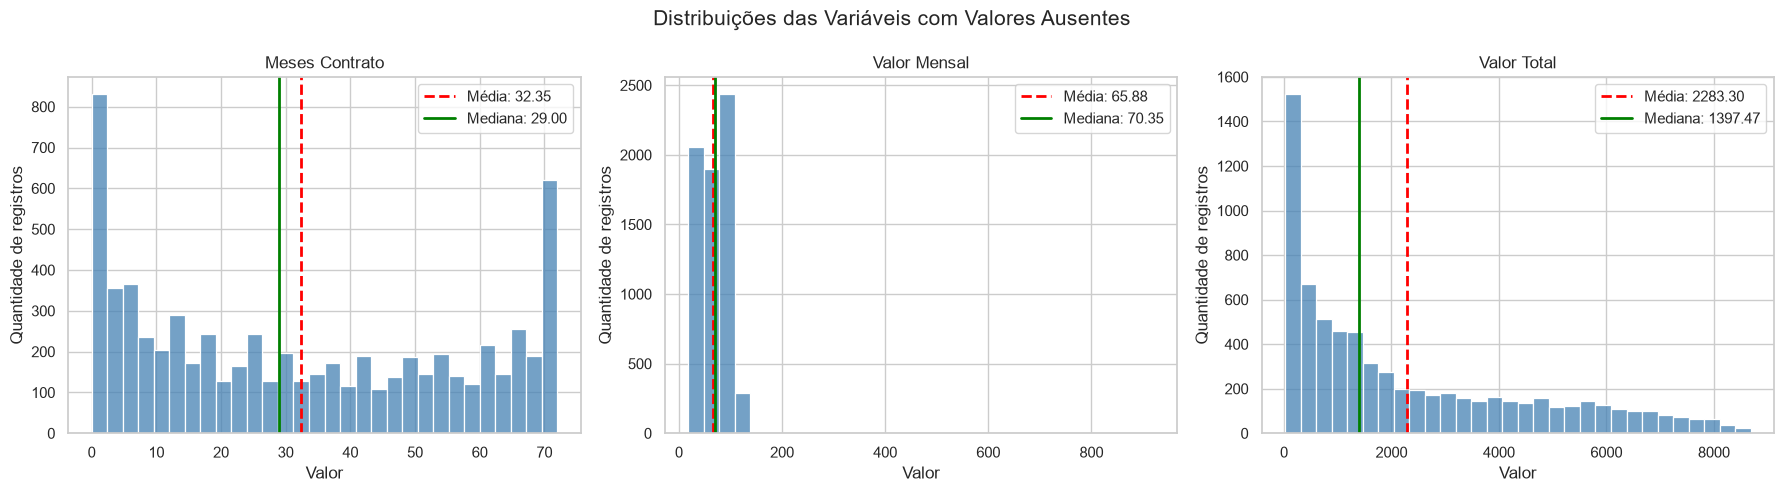

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\04_distribuicoes_para_imputacao.png


In [23]:
# ============================================================
# 2.2 — DISTRIBUIÇÕES PARA DEFINIÇÃO DA IMPUTAÇÃO
# ============================================================

# Garante a existência do diretório de figuras
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

# Cria um histograma para cada variável com valores ausentes
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(colunas_numericas_ausentes),
    figsize=(18, 5)
)

for ax, coluna in zip(axes, colunas_numericas_ausentes):

    dados = df_tratado[coluna].dropna()

    media = dados.mean()
    mediana = dados.median()

    sns.histplot(
        dados,
        bins=30,
        color="steelblue",
        ax=ax
    )

    ax.axvline(
        media,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Média: {media:.2f}"
    )

    ax.axvline(
        mediana,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}"
    )

    ax.set_title(coluna.replace("_", " ").title())
    ax.set_xlabel("Valor")
    ax.set_ylabel("Quantidade de registros")
    ax.legend()

fig.suptitle(
    "Distribuições das Variáveis com Valores Ausentes",
    fontsize=15
)

plt.tight_layout()

# Salva o gráfico
CAMINHO_GRAFICO = (
    DIRETORIO_FIGURAS / "04_distribuicoes_para_imputacao.png"
)

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A análise das distribuições revelou comportamentos distintos entre as variáveis com valores ausentes:

- **`meses_contrato`:** apresenta baixa assimetria (0,24), mas concentrações nas extremidades da distribuição.
- **`valor_mensal`:** apresenta forte assimetria positiva (7,88), com valores extremos que influenciam a média.
- **`valor_total`:** apresenta assimetria positiva (0,96), com concentração de registros em valores mais baixos.

Diante dessas características, **a mediana foi selecionada como estratégia de imputação para as três variáveis**, por ser uma medida de tendência central menos sensível a valores extremos.

A escolha busca preservar a representatividade das distribuições sem introduzir distorções excessivas decorrentes de valores atípicos.

#### Aplicação da Imputação pela Mediana

A estratégia de imputação foi definida com base na análise das distribuições das variáveis numéricas.

Será utilizado o `SimpleImputer` do scikit-learn, configurado para substituir valores ausentes pela mediana.

Para evitar vazamento de dados (*data leakage*), o ajuste definitivo do imputador será realizado exclusivamente sobre os dados de treinamento. Nesta etapa, será validada sua aplicação sem modificar o dataset original.

In [25]:
# ============================================================
# 2.2 — VALIDAÇÃO DA IMPUTAÇÃO PELA MEDIANA
# ============================================================

# Cria uma cópia para demonstrar o tratamento
df_imputacao = df_tratado.copy()

# Cria e ajusta o imputador para análise demonstrativa
imputador = criar_imputador()

df_imputacao[COLUNAS_IMPUTACAO] = imputador.fit_transform(
    df_imputacao[COLUNAS_IMPUTACAO]
)

# Compara valores ausentes antes e depois
comparacao_ausentes = pd.DataFrame({
    "Antes": df_tratado[COLUNAS_IMPUTACAO].isna().sum(),
    "Depois": df_imputacao[COLUNAS_IMPUTACAO].isna().sum()
})

display(comparacao_ausentes)

print("Imputação demonstrativa concluída.")
print("Dataset original preservado.")

,Antes,Depois
meses_contrato,282,0
valor_mensal,352,0
valor_total,11,0


Imputação demonstrativa concluída.
Dataset original preservado.


#### Observações

A imputação pela mediana eliminou os valores ausentes das três variáveis analisadas: `meses_contrato` (282), `valor_mensal` (352) e `valor_total` (11).

O procedimento foi validado por testes automatizados com `pytest` e aplicado a uma cópia dos dados, preservando o dataset original.

Esta execução demonstra a eficácia da estratégia escolhida. Na modelagem, as medianas deverão ser calculadas exclusivamente com os dados de treinamento, evitando vazamento de informações.

### 2.3 — Identificação de Outliers com Boxplots

Nesta etapa, serão analisadas as variáveis numéricas explicativas `meses_contrato`, `valor_mensal` e `valor_total`, utilizando gráficos do tipo boxplot.

Os boxplots permitem visualizar a mediana, os quartis, a dispersão e possíveis valores atípicos, identificados pelo critério do intervalo interquartil (IQR).

A análise será realizada sobre os dados após a remoção de duplicatas, antes da imputação, para preservar a distribuição original dos valores observados.

Os possíveis outliers serão investigados, sem exclusão automática de registros.

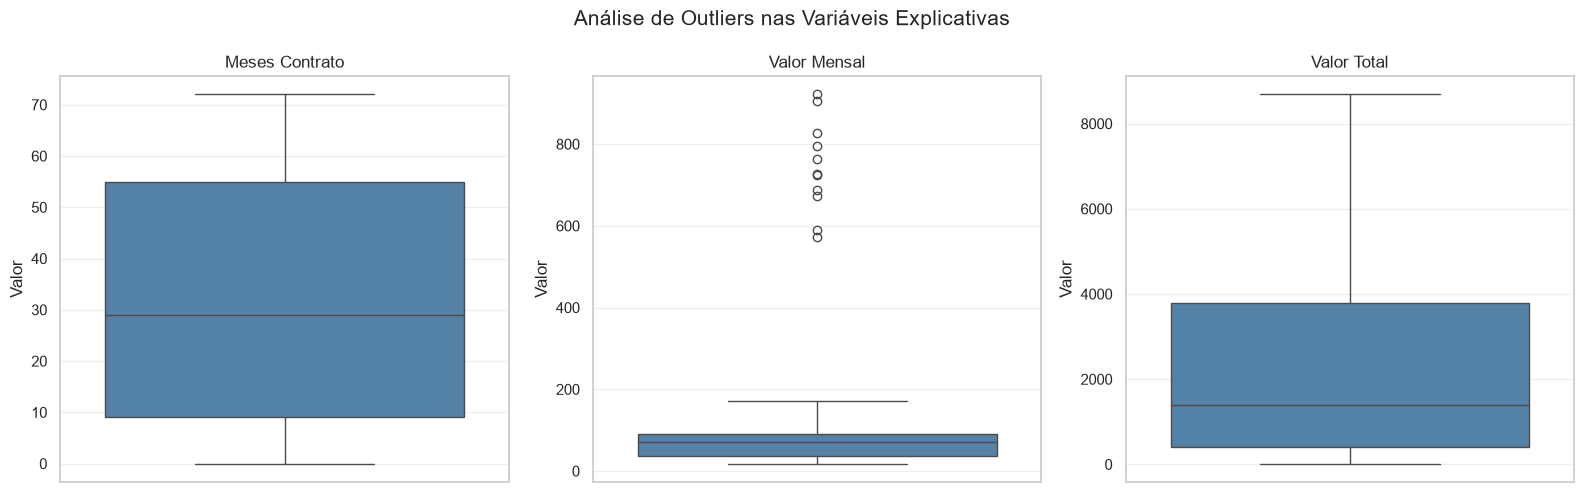

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\05_boxplots_variaveis_explicativas.png


In [26]:
# ============================================================
# 2.3 — IDENTIFICAÇÃO DE OUTLIERS COM BOXPLOTS
# ============================================================

# Variáveis numéricas explicativas
colunas_boxplot = [
    "meses_contrato",
    "valor_mensal",
    "valor_total"
]

# Diretório de saída
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

# Construção dos boxplots
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(colunas_boxplot),
    figsize=(16, 5)
)

for ax, coluna in zip(axes, colunas_boxplot):

    sns.boxplot(
        y=df_tratado[coluna].dropna(),
        color="steelblue",
        ax=ax
    )

    ax.set_title(coluna.replace("_", " ").title())
    ax.set_ylabel("Valor")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Análise de Outliers nas Variáveis Explicativas",
    fontsize=15
)

plt.tight_layout()

# Salvamento automático
CAMINHO_GRAFICO = (
    DIRETORIO_FIGURAS / "05_boxplots_variaveis_explicativas.png"
)

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A análise dos boxplots revelou comportamentos distintos entre as três variáveis explicativas:

- **`meses_contrato`:** não foram identificados outliers pelo critério do intervalo interquartil (IQR). Os valores observados variam aproximadamente de 0 a 72 meses.
- **`valor_mensal`:** foram identificados valores atípicos elevados, aproximadamente entre 570 e 921,40, bastante superiores à concentração principal dos dados. Esses registros merecem investigação para determinar se representam valores legítimos ou inconsistências.
- **`valor_total`:** não foram identificados outliers pelo critério IQR, embora a variável apresente ampla dispersão e assimetria positiva.

Os resultados reforçam a escolha da **mediana como estratégia de imputação**, especialmente para `valor_mensal`, devido à influência potencial dos valores extremos sobre a média.

Nenhum registro foi excluído automaticamente com base nos boxplots, preservando os dados para avaliação posterior.

### 2.4 — Conclusão da Limpeza e Tratamento de Dados

A etapa de preparação dos dados permitiu identificar e remover **25 registros duplicados**, reduzindo o dataset de 7.068 para **7.043 registros**, sem identificadores de clientes repetidos.

Foram identificados valores ausentes em `meses_contrato` (282), `valor_mensal` (352) e `valor_total` (11). A análise das distribuições fundamentou a escolha da **mediana** como estratégia de imputação, cuja aplicação demonstrativa eliminou os valores ausentes dessas variáveis.

Os boxplots identificaram **valores atípicos elevados em `valor_mensal`**, sem evidências de outliers pelo critério IQR nas demais variáveis analisadas. Nenhum registro foi removido exclusivamente por apresentar valores extremos.

As rotinas de remoção de duplicatas e imputação foram organizadas em módulos reutilizáveis e validadas por **7 testes automatizados com `pytest`**. O dataset original foi preservado, e o ajuste definitivo da imputação permanece condicionado à separação dos dados de treinamento, evitando *data leakage*.

## Fase 3 — Feature Engineering

### 3.1 — Criação da Variável `gasto_medio_mensal`

Nesta etapa, será criada uma nova variável numérica a partir da relação entre o valor total acumulado e o tempo de permanência do cliente:

**gasto_medio_mensal = valor_total / meses_contrato**

A implementação utiliza uma função reutilizável, desenvolvida em `src/features/engineering.py` e validada por testes automatizados com `pytest`.

Valores ausentes e contratos com zero meses são considerados no cálculo para evitar divisões inválidas. A imputação definitiva será ajustada exclusivamente com os dados de treinamento, prevenindo *data leakage*.

In [29]:
# ============================================================
# 3.1 — CRIAÇÃO DA VARIÁVEL GASTO MÉDIO MENSAL
# ============================================================

# Utiliza o dataset após a remoção das duplicatas
df_features = criar_gasto_medio_mensal(df_tratado)

# Exibe uma amostra do novo atributo
print("Amostra da variável criada:")
display(
    df_features[
        ["valor_total", "meses_contrato", "gasto_medio_mensal"]
    ].head(10).round(2)
)

# Verifica valores ausentes e infinitos
total_ausentes = df_features["gasto_medio_mensal"].isna().sum()
total_infinitos = np.isinf(
    df_features["gasto_medio_mensal"].dropna()
).sum()

print(f"\nValores ausentes: {total_ausentes}")
print(f"Valores infinitos: {total_infinitos}")

Amostra da variável criada:


,valor_total,meses_contrato,gasto_medio_mensal
0,29.85,1.0,29.85
1,1889.50,34.0,55.57
2,108.15,2.0,54.08
3,1840.75,45.0,40.91
4,151.65,2.0,75.82
5,820.50,8.0,102.56
6,1949.40,22.0,88.61
7,301.90,10.0,30.19
8,3046.05,28.0,108.79
9,3487.95,NaN,NaN



Valores ausentes: 293
Valores infinitos: 0


### 3.2 — Análise da Disponibilidade da Nova Variável

Para avaliar a qualidade da variável `gasto_medio_mensal`, será apresentado um gráfico com a quantidade de registros válidos e os motivos que impediram o cálculo.

Serão considerados valores ausentes em `valor_total`, valores ausentes em `meses_contrato` e contratos com duração igual a zero.

A visualização permitirá compreender a origem dos valores não calculados e documentar as necessidades de tratamento da nova variável.

,Quantidade
Valor total ausente,11
Meses de contrato ausentes,282
Contrato com zero meses,0
Cálculo válido,6750


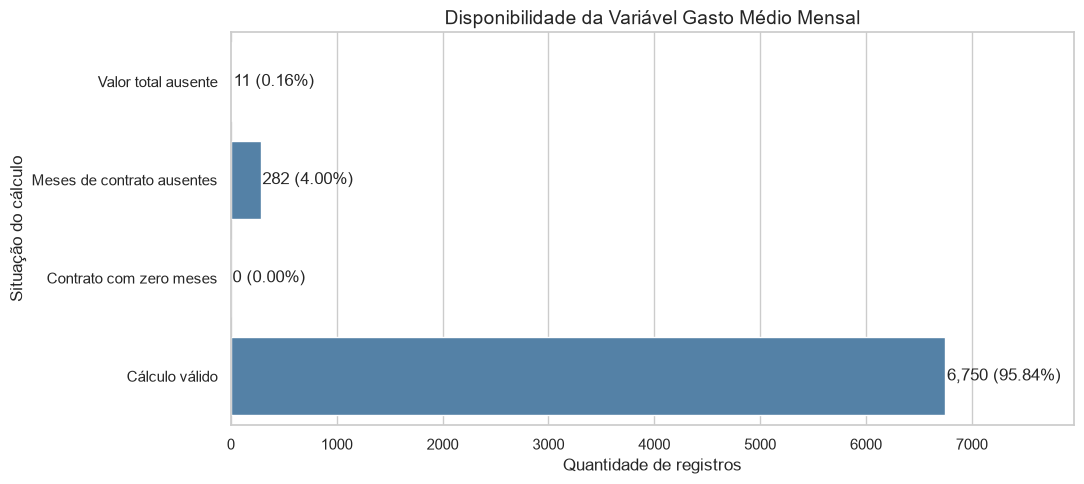

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\06_disponibilidade_gasto_medio_mensal.png


In [30]:
# ============================================================
# 3.2 — DISPONIBILIDADE DA VARIÁVEL GASTO MÉDIO MENSAL
# ============================================================

# Classifica cada registro em uma única categoria
condicoes = [
    df_features["valor_total"].isna(),
    df_features["meses_contrato"].isna(),
    df_features["meses_contrato"].eq(0),
    df_features["gasto_medio_mensal"].notna()
]

categorias = [
    "Valor total ausente",
    "Meses de contrato ausentes",
    "Contrato com zero meses",
    "Cálculo válido"
]

classificacao = np.select(
    condicoes,
    categorias,
    default="Outros casos inválidos"
)

# Contagem por categoria
contagem = pd.Series(classificacao).value_counts()
contagem = contagem.reindex(categorias, fill_value=0)

# Verifica a consistência das classificações
assert contagem.sum() == len(df_features)
assert contagem.iloc[:3].sum() == total_ausentes

# Exibe os resultados
display(contagem.to_frame(name="Quantidade"))

# Cria o gráfico
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    x=contagem.values,
    y=contagem.index,
    color="steelblue",
    ax=ax
)

# Adiciona quantidades e percentuais
for i, quantidade in enumerate(contagem.values):
    percentual = quantidade / len(df_features) * 100

    ax.text(
        quantidade + 15,
        i,
        f"{quantidade:,} ({percentual:.2f}%)",
        va="center"
    )

ax.set_title(
    "Disponibilidade da Variável Gasto Médio Mensal",
    fontsize=14
)
ax.set_xlabel("Quantidade de registros")
ax.set_ylabel("Situação do cálculo")
ax.set_xlim(0, contagem.max() * 1.18)

plt.tight_layout()

# Salva o gráfico
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

CAMINHO_GRAFICO = (
    DIRETORIO_FIGURAS / "06_disponibilidade_gasto_medio_mensal.png"
)

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A variável `gasto_medio_mensal` foi calculada com sucesso para **6.750 clientes (95,84%)**, utilizando a relação entre o valor total acumulado e os meses de contrato.

Os **293 registros sem cálculo (4,16%)** foram classificados em:

- **282 registros (4,00%)** com `meses_contrato` ausente.
- **11 registros (0,16%)** com `valor_total` ausente.

Não foram identificados casos de divisão por zero nem valores infinitos.

A nova variável foi implementada em um módulo reutilizável e validada por **7 testes automatizados com `pytest`**. Os valores ausentes foram preservados para tratamento posterior, evitando imputações calculadas sobre todo o dataset antes da separação entre treinamento e teste.

### 3.3 — Conclusão da Feature Engineering

A Fase 3 resultou na criação da variável numérica `gasto_medio_mensal`, ampliando o conjunto de atributos disponíveis para a análise preditiva.

O cálculo apresentou **95,84% de registros válidos**, sem produzir valores infinitos ou modificar o dataset original. A implementação modular e os testes automatizados garantem a verificabilidade da transformação.

## Fase 4 — Divisão e Balanceamento dos Dados

### 4.1 — Separação das Variáveis e Divisão Estratificada

Nesta etapa, as variáveis preditoras (`X`) serão separadas da variável-alvo (`y`), representada pela coluna `cancelou`.

O conjunto de dados será dividido em **80% para treinamento e 20% para teste**, utilizando `stratify=y` para preservar aproximadamente a proporção de clientes que cancelaram e não cancelaram em ambos os conjuntos.

A coluna `id_cliente` será excluída das variáveis preditoras por representar apenas um identificador.

A divisão será realizada por uma função reutilizável, implementada em `src/splitting/split.py` e validada com testes automatizados utilizando `pytest`.

In [32]:
# ============================================================
# 4.1 — SEPARAÇÃO E DIVISÃO ESTRATIFICADA DOS DADOS
# ============================================================

# Utiliza o dataset após a engenharia de atributos
X_train, X_test, y_train, y_test = dividir_dados(df_features)

# Exibe as dimensões dos conjuntos
print(f"Treinamento: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")
print(f"Total: {len(X_train) + len(X_test)} registros")

# Compara a distribuição percentual da variável-alvo
distribuicao_classes = pd.DataFrame({
    "Dataset completo (%)": df_features["cancelou"].value_counts(normalize=True) * 100,
    "Treinamento (%)": y_train.value_counts(normalize=True) * 100,
    "Teste (%)": y_test.value_counts(normalize=True) * 100
}).sort_index().round(2)

distribuicao_classes.index = [
    "Não cancelou",
    "Cancelou"
]

print("\nDistribuição das classes:")
display(distribuicao_classes)

Treinamento: 5634 registros
Teste: 1409 registros
Total: 7043 registros

Distribuição das classes:


,Dataset completo (%),Treinamento (%),Teste (%)
Não cancelou,73.46,73.46,73.46
Cancelou,26.54,26.54,26.54


### 4.2 — Comparação da Distribuição das Classes

Será apresentado um gráfico comparativo da distribuição percentual da variável-alvo `cancelou` no dataset completo e nos conjuntos de treinamento e teste.

O objetivo é verificar visualmente se a divisão estratificada preservou a proporção das classes, conforme estabelecido na etapa anterior.

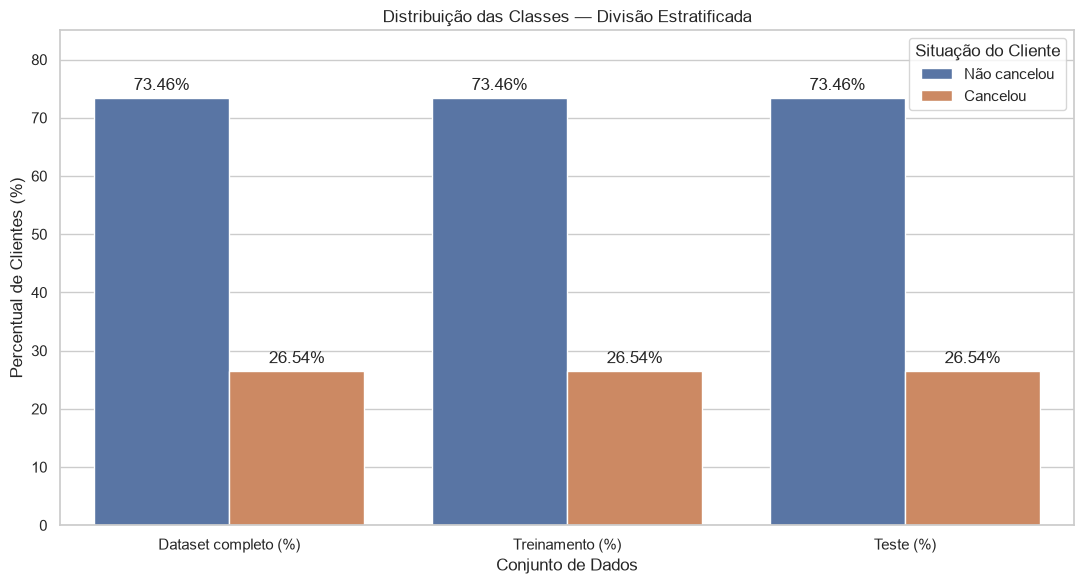

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\07_distribuicao_classes_treino_teste.png


In [33]:
# ============================================================
# 4.2 — COMPARAÇÃO DA DISTRIBUIÇÃO DAS CLASSES
# ============================================================

# Prepara os dados para visualização
dados_grafico = (
    distribuicao_classes
    .reset_index()
    .rename(columns={"index": "Situação"})
    .melt(
        id_vars="Situação",
        var_name="Conjunto",
        value_name="Percentual"
    )
)

# Cria o gráfico
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=dados_grafico,
    x="Conjunto",
    y="Percentual",
    hue="Situação",
    ax=ax
)

# Adiciona os percentuais sobre as barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

ax.set_title("Distribuição das Classes — Divisão Estratificada")
ax.set_xlabel("Conjunto de Dados")
ax.set_ylabel("Percentual de Clientes (%)")
ax.set_ylim(0, 85)
ax.legend(title="Situação do Cliente")

plt.tight_layout()

# Salva o gráfico
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

CAMINHO_GRAFICO = (
    DIRETORIO_FIGURAS / "07_distribuicao_classes_treino_teste.png"
)

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A divisão estratificada distribuiu os **7.043 registros** em **5.634 para treinamento (80%)** e **1.409 para teste (20%)**.

O parâmetro `stratify=y` preservou a proporção das classes nos dois conjuntos, mantendo **73,46% de clientes que não cancelaram** e **26,54% que cancelaram**.

Os resultados confirmam a consistência da divisão e evidenciam o desbalanceamento original da variável-alvo, com predominância de clientes que permaneceram no serviço.

### 4.3 — Balanceamento dos Dados de Treinamento

Nesta etapa, será aplicada a técnica **Random Under Sampling**, que reduz aleatoriamente os registros da classe majoritária até igualar a quantidade de observações da classe minoritária.

O procedimento será realizado **exclusivamente no conjunto de treinamento**, preservando os dados de teste e evitando *data leakage*.

A implementação utiliza a função `balancear_treinamento()`, definida em `src/splitting/balancing.py` e validada por testes automatizados com `pytest`.

In [35]:
# ============================================================
# 4.3 — BALANCEAMENTO DOS DADOS DE TREINAMENTO
# ============================================================

# Preserva os conjuntos originais
X_train_original = X_train.copy()
y_train_original = y_train.copy()

# Aplica Random Under Sampling somente ao treinamento
X_train_bal, y_train_bal = balancear_treinamento(
    X_train,
    y_train,
    random_state=42
)

# Compara a distribuição das classes
comparacao_balanceamento = pd.DataFrame({
    "Antes": y_train.value_counts().sort_index(),
    "Depois": y_train_bal.value_counts().sort_index()
})

comparacao_balanceamento.index = [
    "Não cancelou",
    "Cancelou"
]

print("Distribuição das classes antes e depois do balanceamento:")
display(comparacao_balanceamento)

print(f"\nTreinamento original: {len(X_train)} registros")
print(f"Treinamento balanceado: {len(X_train_bal)} registros")
print(f"Conjunto de teste preservado: {len(X_test)} registros")

Distribuição das classes antes e depois do balanceamento:


,Antes,Depois
Não cancelou,4139,1495
Cancelou,1495,1495



Treinamento original: 5634 registros
Treinamento balanceado: 2990 registros
Conjunto de teste preservado: 1409 registros


### 4.4 — Comparação das Classes Antes e Depois do Balanceamento

Será apresentado um gráfico comparativo da quantidade de clientes em cada classe antes e depois da aplicação do **Random Under Sampling**.

A visualização permitirá verificar o equilíbrio obtido no conjunto de treinamento e identificar a redução de registros da classe majoritária.

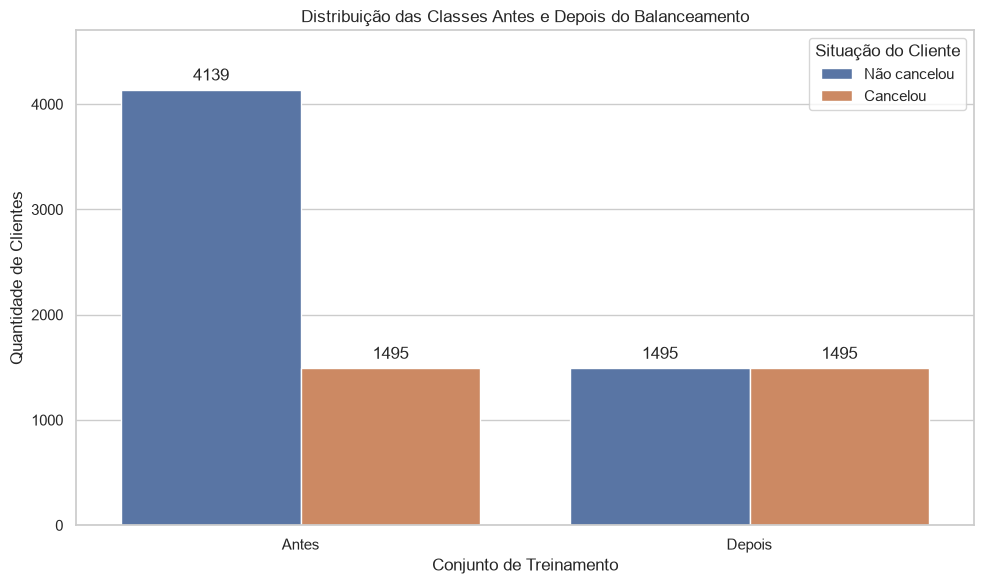

Gráfico salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\08_balanceamento_classes_treinamento.png


In [36]:
# ============================================================
# 4.4 — COMPARAÇÃO ANTES E DEPOIS DO BALANCEAMENTO
# ============================================================

# Organiza os dados para o gráfico
dados_grafico = (
    comparacao_balanceamento
    .reset_index()
    .rename(columns={"index": "Situação"})
    .melt(
        id_vars="Situação",
        var_name="Etapa",
        value_name="Quantidade"
    )
)

# Cria o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=dados_grafico,
    x="Etapa",
    y="Quantidade",
    hue="Situação",
    ax=ax
)

# Adiciona os valores sobre as barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4)

ax.set_title("Distribuição das Classes Antes e Depois do Balanceamento")
ax.set_xlabel("Conjunto de Treinamento")
ax.set_ylabel("Quantidade de Clientes")
ax.set_ylim(0, 4700)
ax.legend(title="Situação do Cliente")

plt.tight_layout()

# Salva o gráfico
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

CAMINHO_GRAFICO = (
    DIRETORIO_FIGURAS / "08_balanceamento_classes_treinamento.png"
)

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

O conjunto de treinamento apresentava desbalanceamento entre as classes, com **4.139 clientes que não cancelaram** e **1.495 que cancelaram**.

Após a aplicação do **Random Under Sampling**, ambas as classes passaram a apresentar **1.495 registros**, resultando em uma distribuição equilibrada de **50% para cada classe**.

A técnica removeu **2.644 registros da classe majoritária**, preservando integralmente a classe minoritária. Essa redução representa uma perda de informações que deverá ser considerada na avaliação dos modelos.

O balanceamento foi aplicado exclusivamente aos dados de treinamento, enquanto os **1.409 registros do conjunto de teste permaneceram inalterados**, preservando a distribuição original para avaliação.

### 4.5 — Conclusão da Divisão e Balanceamento dos Dados

A Fase 4 realizou a divisão estratificada dos **7.043 registros**, destinando **80% ao treinamento e 20% ao teste**, com preservação das proporções da variável-alvo.

O balanceamento por **Random Under Sampling** resultou em **2.990 registros de treinamento**, distribuídos igualmente entre as duas classes.

As operações foram implementadas em módulos reutilizáveis, mantendo o conjunto de teste separado e preservando a reprodutibilidade dos resultados.